<a href="https://colab.research.google.com/github/theofloris/Telco-Customer-Churn-Prediction/blob/main/Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisi e sviluppo di un modello predittivo per il tasso di abbandono dei clienti nel campo delle telecomunicazioni


## Introduzione

In questo notebook sarà possibile visualizzare un'intera pipeline nella quale viene analizzato concretamente il tasso di abbandono dei clienti nel settore delle telecomunicazioni. Il notebook vuole dimostrare l'importanza di analizzare e predirre nella maniera corretta ed efficace l'andamento del tasso di abbandono dei clienti succitati.

## Una prima analisi

Il Dataset utilizzato per la dimostrazione, è il seguente: [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn?resource=download).
Esso, come descritto sulla pagina di Kaggle stessa, è strutturato in questo modo: ogni riga rappresenta un cliente, ogni colonna contiene gli attributi del cliente descritti nella colonna Metadati.

Per comprendere al meglio la struttura e il contenuto del dataset in questione, è necessario visualizzare più nel dettaglio ciò che quest'ultimo contiene. Per fare questo andrò ad utilizzare alcune librerie allo stato dell'arte, come: `pandas`, `numpy`, `matplotlib`. Prima di fare questo, è però necessario caricare il file .csv su Colab.

In [ ]:
"""
Cella esclusiva per l'import delle librerie necessarie
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

La prima analisi preliminare che ho voluto fare è utilizzando la famosa funzione `shape()` di `pandas`. In questo modo ottengo subito due informazioni cruciali riguardanti il dataset:


*   Il **numero di clienti** presenti nel dataset (righe).
*   Il **numero di feature** (attributi) utilizzati per descrivere i clienti (colonne).

E osserviamo immediamente come il dataset abbia una shape (7.043 x 21)



In [ ]:
df = pd.read_csv('/content/Telco Customer Churn.csv')

print("Numero di righe (clienti):", df.shape[0])
print("Numero di colonne (features):", df.shape[1])

Numero di righe (clienti): 7043
Numero di colonne (features): 21


Un ulteriore e interessante analisi preliminare è quella fattibile grazie alla funzione `info()`. Infatti, grazie a questa funzione sono visualizzabili alcuni aspetti del dataset di non trascurabile rilevanza, tra cui:



1.   **Etichette** delle feature presenti nel dataset;
2.   Presenza/Assenza di "missing data", grazie alla visualizzazione dei "**Non-null Count**";
3.   Visualizzazione della **tipologia di dato** associato alla feature: object, int64, float64, ...



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Infine, per completezza è corretto visualizzare una porzione del dataset, in questo caso utilizzando la funzione `head()`e visualizzare i principali indici statistici calcolati sui dati numerici (int64 e float64 nel nostro caso) grazie alla funzione `describe()`.

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Questa analisi finale, mi fa notare una piccola discrepanza nei dati. Infatti Notiamo che nella cella sopra, sono stati calcolati gli indici statistici sulle feature `SeniorCitizen`, `tenure` e `MonthlyCharges`. Come possiamo vedere dalla cella ancora precedente però, nella quale è stata eseguita la funzione `head()`, notiamo che è presente un'ulteriore variabile numerica, ovvero `TotalCharges`, che viene identificata però con un DType object. In questo caso, risulta una buona pratica convertirla in float64, e inoltre possiamo scartare la colonna customerID, che risulta inutile per il proseguo dell'analisi, segue:

In [ ]:
df_cleaned = df.copy()

df_cleaned = df_cleaned.drop('customerID', axis = 1) # rimuove la feature customerID

df_cleaned['TotalCharges'] = pd.to_numeric(df_cleaned['TotalCharges'], errors = 'coerce') # converte la feature TotalCharges in numerico (float64)

df_cleaned.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


Verificando ora se il nostro procedimento ha funzionato, notiamo come le feature non sono più 21, ma 20 (abbiamo "droppato" la colonna customerID), inoltre notiamo immediatamente come TotalCharges sia ora effettivamente un dato numerico di tipo Dtype float64. Possiamo, infine notare, una cosa molto interessante. Analizzando la colonna `Non-Null Count`vediamo un'interessante novità, ovvero il suo valore in corrispondenza della feature TotalCharges non è più 7.043, ma 7.032. Questo significa che ci troviamo di fronte ad una **mancanza di dati**. Verifichiamola:

In [ ]:
print("Totale Valori Nulli:", df_cleaned['TotalCharges'].isnull().sum())

Totale Valori Nulli: 11


Possiamo gestire questa situazione in diversi modi. Il modo più semplice, è sicuramente quello di eliminare dal dataset le righe che contengono un valore nullo, questo perché su 7.043 righe, togliendone 11 non si andrebbe ad alterare il dataset e rimarrebbe sicuramente stabile in termini di media, deviazione standard, quartili, massimo e minimo. Farò ora una verifica per dimostrarlo.  

In [ ]:
if df_cleaned['TotalCharges'].isnull().sum() > 0:
  df_cleaned = df_cleaned.dropna(subset=['TotalCharges'])

df_cleaned.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Concludiamo questa fase mostrando la shape finale del dataset pulito e pronto per il prossimo step:

In [ ]:
print("Shape finale del dataset dopo la prima fase di pre-processing:", df_cleaned.shape)

Shape finale del dataset dopo la prima fase di pre-processing: (7032, 20)


## Visualizzazione dei dati

/tmp/ipython-input-552097623.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='Churn', ax=axes[0], palette='Set1')


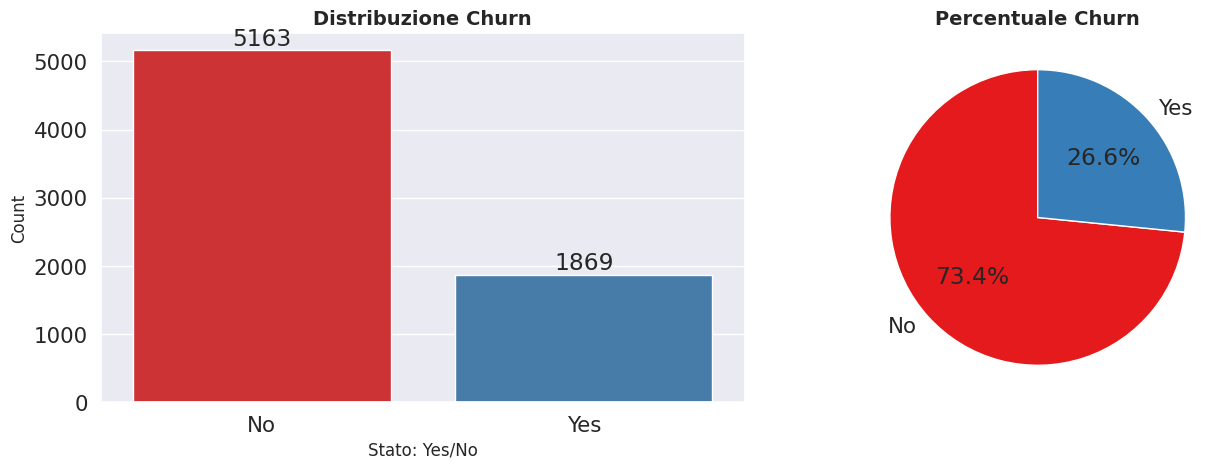

In [ ]:
# Distribuzione Churn
churn_counts = df_cleaned['Churn'].value_counts()
churn_pct = df_cleaned['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df_cleaned, x='Churn', ax=axes[0], palette='Set1')
axes[0].set_title('Distribuzione Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Stato: Yes/No', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
for container in axes[0].containers:
    axes[0].bar_label(container)

# Pie chart
axes[1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette('Set1'))
axes[1].set_title('Percentuale Churn', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipython-input-2759733538.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='Churn', y='tenure', palette='Set1', ax=axes[2])


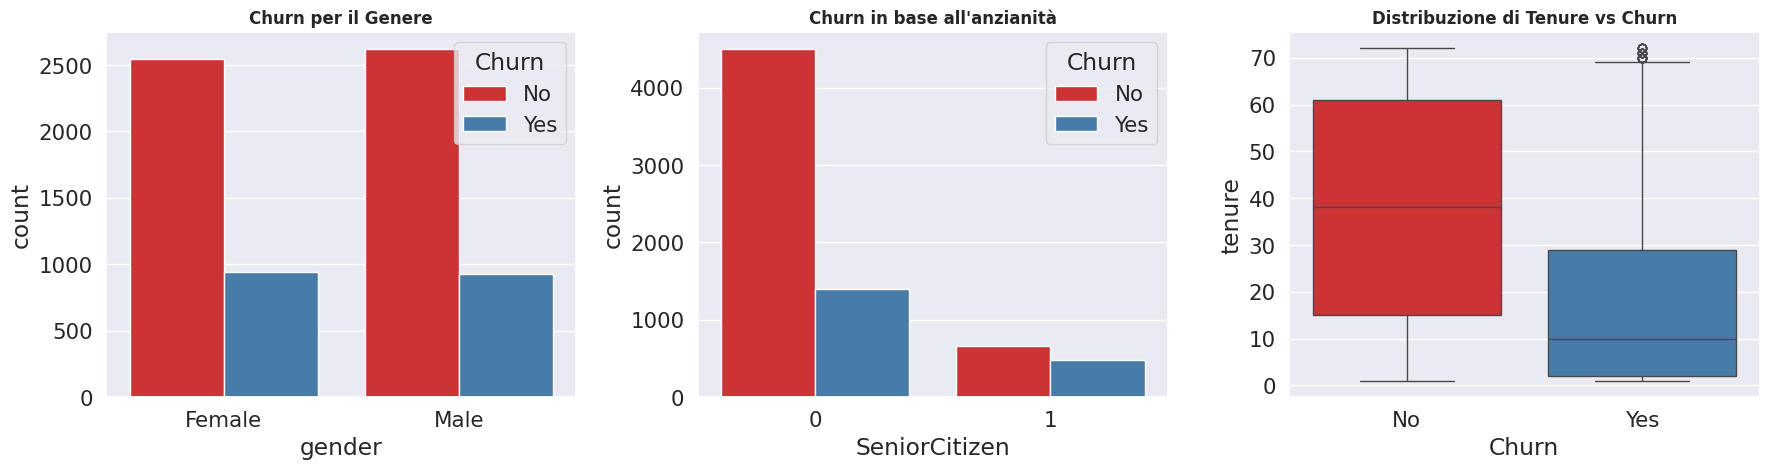

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Gender vs Churn
sns.countplot(data=df_cleaned, x='gender', hue='Churn', ax=axes[0], palette='Set1')
axes[0].set_title('Churn per il Genere', fontsize=12, fontweight='bold')

# 2. Senior Citizen vs Churn
sns.countplot(data=df_cleaned, x='SeniorCitizen', hue='Churn', ax=axes[1], palette='Set1')
axes[1].set_title('Churn in base all\'anzianità', fontsize=12, fontweight='bold')

# 3. Box Plot (CORRETTO: usiamo axes[2])
sns.boxplot(data=df_cleaned, x='Churn', y='tenure', palette='Set1', ax=axes[2])
axes[2].set_title('Distribuzione di Tenure vs Churn', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

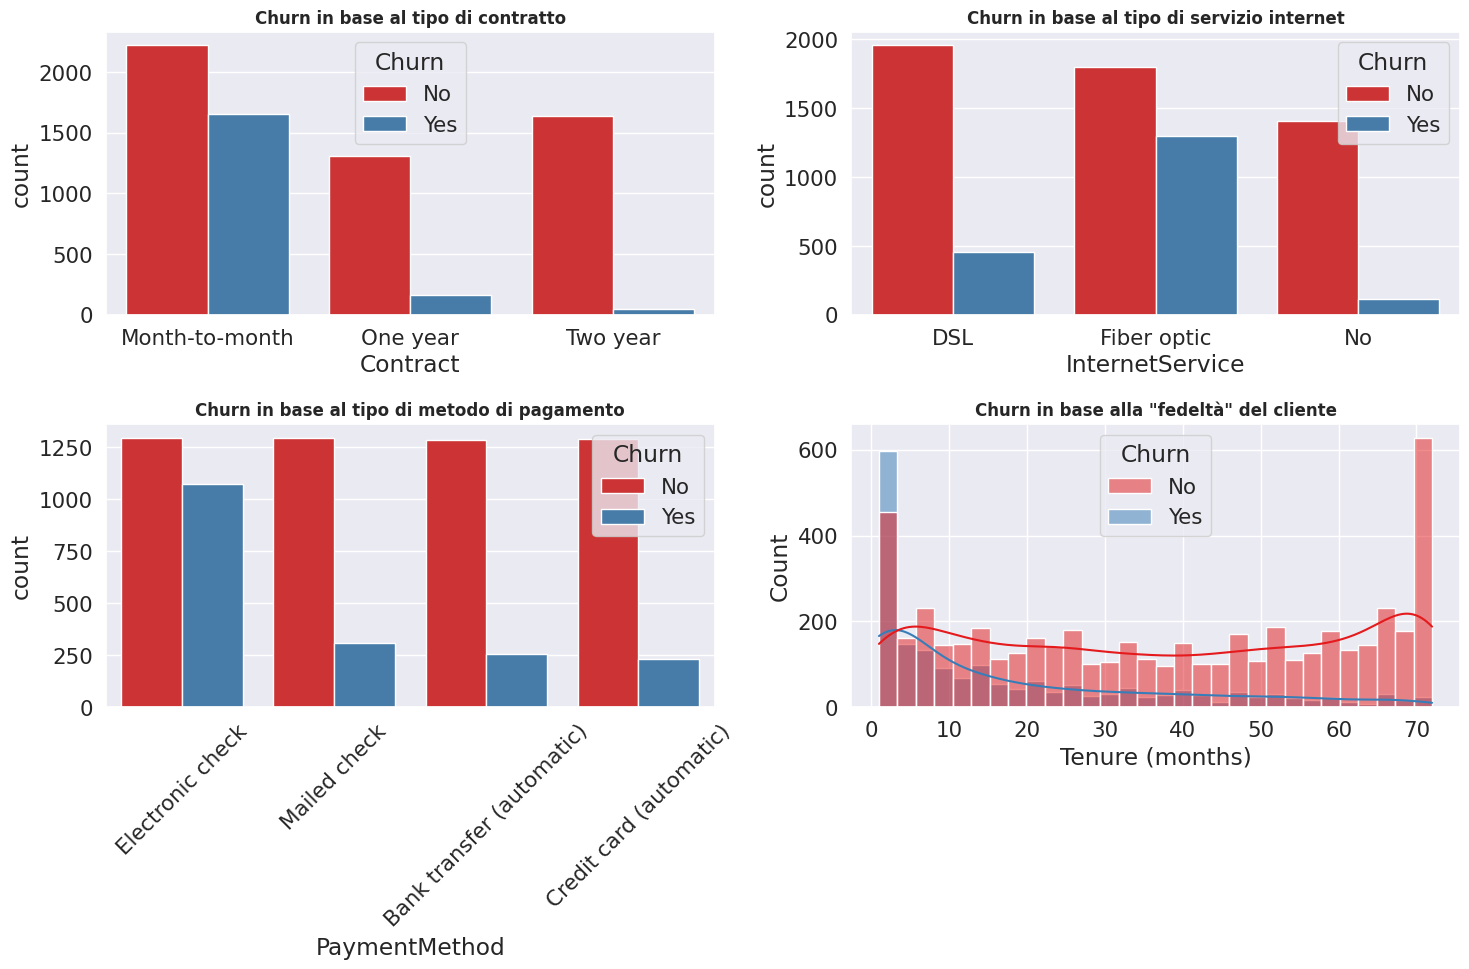

In [ ]:
# Tipo di Contratto vs Churn
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Contratto
sns.countplot(data=df_cleaned, x='Contract', hue='Churn', ax=axes[0, 0], palette='Set1')
axes[0, 0].set_title('Churn in base al tipo di contratto', fontsize=12, fontweight='bold')
axes[0, 0].legend(title='Churn')

# Internet Service
sns.countplot(data=df_cleaned, x='InternetService', hue='Churn', ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('Churn in base al tipo di servizio internet', fontsize=12, fontweight='bold')
axes[0, 1].legend(title='Churn')

# Payment Method
sns.countplot(data=df_cleaned, x='PaymentMethod', hue='Churn', ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('Churn in base al tipo di metodo di pagamento', fontsize=12, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Churn')

# Tenure
sns.histplot(data=df_cleaned, x='tenure', hue='Churn', bins=30, ax=axes[1, 1], palette='Set1', kde=True)
axes[1, 1].set_title('Churn in base alla "fedeltà" del cliente', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Tenure (months)')

plt.tight_layout()
plt.show()

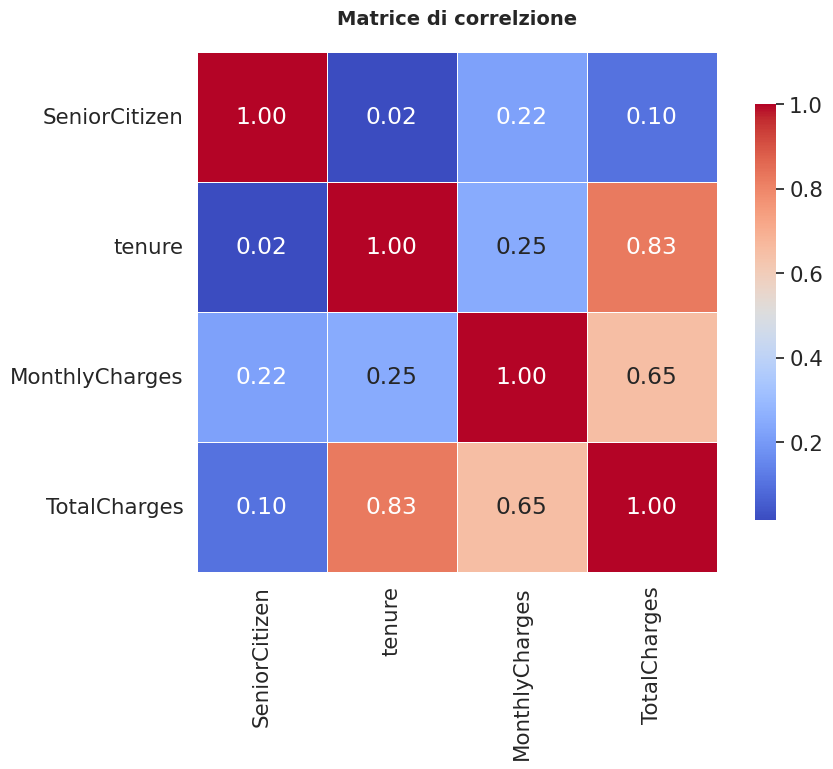

In [ ]:
# Correlation matrix for numerical features
numerical_cols = df_cleaned.select_dtypes(include=[np.number]).columns
correlation_matrix = df_cleaned[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matrice di correlzione', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Pre-Processing dei Dati

Prima di iniziare l'addestramento e la validazione del modello predittivo scelto, è bene processare i dati e renderli conformi per lo scopo.
Processiamo separatamente quindi le variabili:



*   **Categoriche**
*   **Binarie**
*   **Numeriche**

Questo processo è stato eseguito con l'aiuto di **Gemini Pro**, per automatizzare il processo, per aumentare la velocità di scrittura e per dimostrare la conoscenza e capacità nel gesitre AI Generativa. Infatti nel `df_post_process` si vedono 25 colonne contro le 21 iniziali. Questo perché il Pre-Processing ha dato vita a nuove colonne come ad esempio `OnlineBackup_Yes` o `DeviceProtection_Yes`. In quanto per il corretto addestramento del modello è sufficiente sapere se il valore della colonna sia vero o falso.

In [ ]:
df_post_process = df_cleaned.copy()

cols_with_internet_redundancy = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Sostituiamo 'No internet service' con 'No'
for col in cols_with_internet_redundancy:
    df_post_process[col] = df_post_process[col].replace('No internet service', 'No')

# Sostituiamo 'No phone service' con 'No' nella colonna MultipleLines
df_post_process['MultipleLines'] = df_post_process['MultipleLines'].replace('No phone service', 'No')

# Processa le variabili categoriche
categorical_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

df_post_process = pd.get_dummies(df_post_process, columns=categorical_cols, drop_first=True)

# Processa le variabili binarie
binary_cols = [
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

for cols in binary_cols:
    df_post_process[cols] = df_post_process[cols].map({'Yes': 1, 'No': 0})

# Processa la variabile di interesse
df_post_process['Churn'] = df_post_process['Churn'].map({'Yes': 1, 'No': 0})

# Processa la variabile genere
df_post_process['gender'] = df_post_process['gender'].map({'Male': 1, 'Female': 0})

# Verifichiamo che tutto sia andato a buon fine
df_post_process.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,True,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,True,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,True,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,False,True,True,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


## Definizione delle Funzioni per la Addestramento & Valutazione del Modello

In questa sezione del notebook sono presenti le funzioni utili per:

*   **Addestramento** del modello scelto
*   **Visualizzazione dei risultati** ottenuti sul Test set

La funzione `evaluate_model` ha come scopo principale quello di addestrare il modello, e di visualizzare le principali metriche di valutazione:

*   **Accuracy**
*   **Precision**
*   **Recall**
*   **f1 Score**

e restituisce un dizionario che risulta utile per le successive funzioni.

La funzione `confusion_matrix_plot` ha come funzione quella di visualizzare a schermo e in linea generale le prestazioni del modello dal punto di vista di previsioni corrette e non.

Infine, la funzione `plot_roc_curve` ha lo scopo di visuallizzare a schermo la curva ROC, nella quale vengono messe in evidenza le prestazioni del classificatore rispetto ad un classificatore "casuale" ovvero con probabilità di 0.5 (predizione casuale).

In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    # Addestramento
    model.fit(X_train, y_train)

    # Predizioni
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    # Metriche di base
    accuracy = accuracy_score(y_test, y_pred)   # Quante ne ha azzeccate in totale?
    precision = precision_score(y_test, y_pred) # Dei "Sì" che ha detto, quanti erano veri?
    recall = recall_score(y_test, y_pred)       # Di tutti i veri "Sì", quanti ne ha trovati?
    f1 = f1_score(y_test, y_pred)               # Media armonica tra Precision e Recall

    # AUC : Area Under The Curve
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None

    print(f"\n{'='*60}")
    print(f"{model_name}")
    print(f"{'='*60}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    if roc_auc:
        print(f"ROC AUC:   {roc_auc:.4f}")

    return {
        'model': model,
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc
    }

# Visualizza la matrice di confusione
def confusion_matrix_plot(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)

    group_names = ['Veri Negativi (TN)', 'Falsi Positivi (FP)',
                   'Falsi Negativi (FN)', 'Veri Positivi (TP)']
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]

    labels = np.asarray(labels).reshape(2,2)

    plt.figure(figsize=(6, 5))

    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                linewidths=2, linecolor='black',
                annot_kws={"fontsize":11})

    plt.title(f'{model_name} - Matrice di Confusione', fontsize=14, fontweight='bold')
    plt.ylabel('Reale', fontsize=12)
    plt.xlabel('Predetto', fontsize=12)
    plt.tight_layout()
    plt.show()

# Plotta anche la curva ROC
def plot_roc_curve(y_test, y_pred_proba, model_name):
    if y_pred_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = roc_auc_score(y_test, y_pred_proba)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2,
                label=f'{model_name} (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('Rate Falsi Positivi', fontsize=12)
        plt.ylabel('Rate Veri Positivi', fontsize=12)
        plt.title(f'{model_name} - Curva ROC', fontsize=14, fontweight='bold')
        plt.legend(loc='lower right', fontsize=10)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

## Random Forest

Dopo la fase di preprocessing, definiamo le feature ($X$) eliminando accuratamente ogni riferimento alla variabile target per garantire la validità del training.

Il dataset viene suddiviso con una strategia stratificata (stratify=y) per preservare la distribuzione delle classi nel Test Set (30%), garantendo così che la proporzione di clienti che abbandonano rimanga identica in entrambi i set

Utilizziamo un algoritmo Random Forest ottimizzato con una profondità massima (max_depth=10) per bilanciare la capacità di apprendimento e la generalizzazione sui nuovi dati.




Random Forest
Accuracy:  0.7957
Precision: 0.6625
Recall:    0.4724
F1-Score:  0.5515
ROC AUC:   0.8341


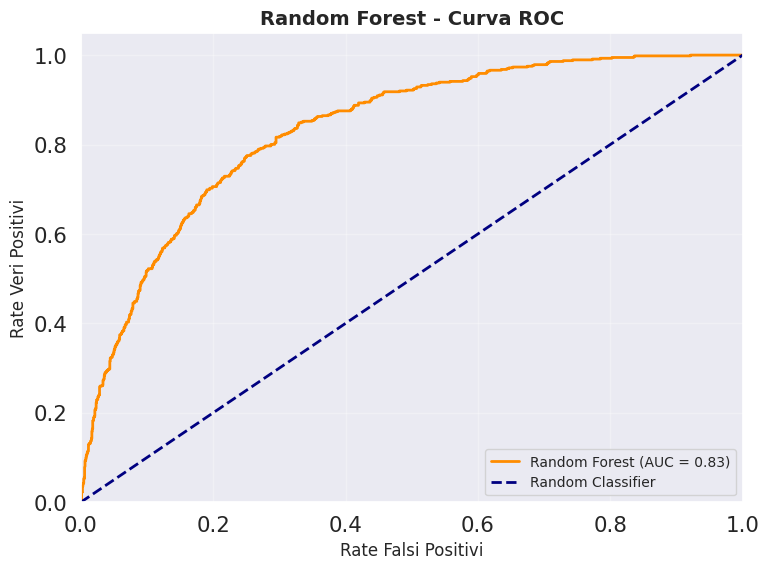

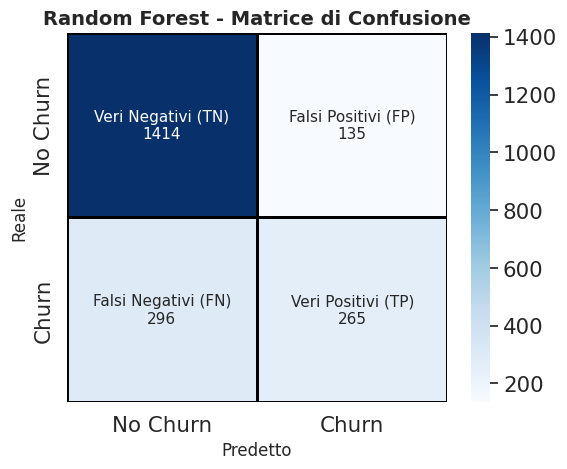

In [ ]:
X = df_post_process.drop('Churn', axis=1)
#X = X.drop('Churn_Numeric', axis=1)
y = df_post_process['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_eval = evaluate_model(rf_model, X_train, X_test, y_train, y_test, 'Random Forest')

plot_roc_curve(y_test, rf_eval['probabilities'], 'Random Forest')
confusion_matrix_plot(y_test, rf_eval['predictions'], 'Random Forest')